# 📘Projet 1: Machine Learning Supervisé (Régression)

# 1.Importing and exploration of Data 

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("D:/AW PRV/AUTO FORMATION/Projets/kc_house_data.csv")
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [3]:
# Exemple
df['date'] = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S')

# Vérifier
print(df['date'].head())

0   2014-10-13
1   2014-12-09
2   2015-02-25
3   2014-12-09
4   2015-02-18
Name: date, dtype: datetime64[ns]


In [4]:
df['transaction_year'] = df['date'].dt.year

In [5]:
df['house_age'] = df['transaction_year'] - df['yr_built']

In [6]:
# Poser la colonne 'date' comme index
df.set_index('date', inplace=True)

# Vérifier
print(df.head())
print(df.index)  # Affiche l'index datetime

                    id     price  bedrooms  bathrooms  sqft_living  sqft_lot  \
date                                                                           
2014-10-13  7129300520  221900.0         3       1.00         1180      5650   
2014-12-09  6414100192  538000.0         3       2.25         2570      7242   
2015-02-25  5631500400  180000.0         2       1.00          770     10000   
2014-12-09  2487200875  604000.0         4       3.00         1960      5000   
2015-02-18  1954400510  510000.0         3       2.00         1680      8080   

            floors  waterfront  view  condition  ...  sqft_basement  yr_built  \
date                                             ...                            
2014-10-13     1.0           0     0          3  ...              0      1955   
2014-12-09     2.0           0     0          3  ...            400      1951   
2015-02-25     1.0           0     0          3  ...              0      1933   
2014-12-09     1.0           0    

In [7]:
# Trier le DataFrame par index (date)
df = df.sort_index()

# Vérifier
print(df.head())    # début du DataFrame (dates les plus anciennes)
print(df.tail())    # fin du DataFrame (dates les plus récentes)

                    id     price  bedrooms  bathrooms  sqft_living  sqft_lot  \
date                                                                           
2014-05-02  5561000190  437500.0         3       2.25         1970     35100   
2014-05-02   472000620  790000.0         3       2.50         2600      4750   
2014-05-02  1024069009  675000.0         5       2.50         2820     67518   
2014-05-02  7853361370  555000.0         4       2.50         3310      6500   
2014-05-02  5056500260  440000.0         4       2.25         2160      8119   

            floors  waterfront  view  condition  ...  sqft_basement  yr_built  \
date                                             ...                            
2014-05-02     2.0           0     0          4  ...              0      1977   
2014-05-02     1.0           0     0          4  ...            900      1951   
2014-05-02     2.0           0     0          3  ...              0      1979   
2014-05-02     2.0           0    

In [8]:
# Nombre de dates uniques vs total
total_dates = len(df)
unique_dates = df.index.nunique()

print(f"Total de lignes : {total_dates}")
print(f"Nombre de dates uniques : {unique_dates}")
print(f"Nombre de répétitions : {total_dates - unique_dates}")

Total de lignes : 21613
Nombre de dates uniques : 372
Nombre de répétitions : 21241


In [9]:
type(df.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [10]:
# 1. Créer un ID virtuel pour distinguer les observations d'une même date
df["virtual_id"] = df.groupby(level=0).cumcount()

# 2. Créer un MultiIndex (Date + ID virtuel)
df = df.set_index("virtual_id", append=True).sort_index()

# 3. Créer un calendrier journalier complet
daily_calendar = pd.date_range(
    start=df.index.get_level_values(0).min(),
    end=df.index.get_level_values(0).max(),
    freq="D"
)

# 4. Reindexer uniquement sur la dimension temporelle (Date)
df = df.reindex(daily_calendar, level=0)

In [11]:
df.index.names
df.index.is_unique

True

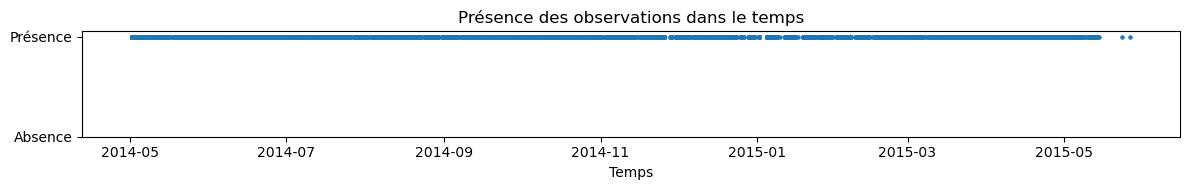

In [12]:
import matplotlib.pyplot as plt

presence = df.notna().any(axis=1).astype(int)

plt.figure(figsize=(12, 2))
plt.scatter(
    presence.index.get_level_values(0),
    presence,
    s=5
)

plt.yticks([0, 1], ["Absence", "Présence"])
plt.title("Présence des observations dans le temps")
plt.xlabel("Temps")
plt.tight_layout()
plt.show()

In [13]:
df

id      price  bedrooms  bathrooms  \
date       virtual_id                                               
2014-05-02 0           5561000190   437500.0         3       2.25   
           1            472000620   790000.0         3       2.50   
           2           1024069009   675000.0         5       2.50   
           3           7853361370   555000.0         4       2.50   
           4           5056500260   440000.0         4       2.25   
...                           ...        ...       ...        ...   
2015-05-14 9           1422700040   183000.0         3       1.00   
           10          8730000270   359000.0         2       2.75   
2015-05-15 0           7923600250   450000.0         5       2.00   
2015-05-24 0           5101400871   445500.0         2       1.75   
2015-05-27 0           9106000005  1310000.0         4       2.25   

                       sqft_living  sqft_lot  floors  waterfront  view  \
date       virtual_id                                                    
2014-05-02 0                  1970     35100     2.0           0     0   
           1                  2600      4750     1.0           0     0   
           2                  2820     67518     2.0           0     0   
           3                  3310      6500     2.0           0     0   
           4                  2160      8119     1.0           0     0   
...                            ...       ...     ...         ...   ...   
2015-05-14 9                  1170      7320     1.0           0     0   
           10                 1370      1140     2.0           0     0   
2015-05-15 0                  1870      7344     1.5           0     0   
2015-05-24 0                  1390      6670     1.0           0     0   
2015-05-27 0                  3750      5000     2.0           0     0   

                       condition  ...  sqft_basement  yr_built  yr_renovated  \
date       virtual_id             ...                                          
2014-05-02 0                   4  ...              0      1977             0   
           1                   4  ...            900      1951             0   
           2                   3  ...              0      1979             0   
           3                   3  ...              0      2012             0   
           4                   3  ...           1080      1966             0   
...                          ...  ...            ...       ...           ...   
2015-05-14 9                   3  ...              0      1962             0   
           10                  3  ...            290      2009             0   
2015-05-15 0                   3  ...              0      1960             0   
2015-05-24 0                   3  ...            670      1941             0   
2015-05-27 0                   5  ...           1310      1924             0   

                       zipcode      lat     long  sqft_living15  sqft_lot15  \
date       virtual_id                                                         
2014-05-02 0             98027  47.4635 -121.991           2340       35100   
           1             98117  47.6833 -122.400           2380        4750   
           2             98029  47.5794 -122.025           2820       48351   
           3             98065  47.5150 -121.870           2380        5000   
           4             98006  47.5443 -122.177           1850        9000   
...                        ...      ...      ...            ...         ...   
2015-05-14 9             98188  47.4685 -122.282           2040        7320   
           10            98133  47.7052 -122.343           1370        1090   
2015-05-15 0             98007  47.5951 -122.144           1870        7650   
2015-05-24 0             98115  47.6914 -122.308            920        6380   
2015-05-27 0             98115  47.6747 -122.303           2170        4590   

                       transaction_year  house_age  
date       virtual_id                           

# 2.Data Cleaning & Feature inginiering

In [14]:
df = df.drop(columns=["id", "transaction_year"])

In [15]:
print("Dimensions :", df.shape)
print("Nombre de features :", df.shape[1])
print("Nombre total de cellules :", df.size)
df.info()

Dimensions : (21613, 20)
Nombre de features : 20
Nombre total de cellules : 432260
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 21613 entries, (Timestamp('2014-05-02 00:00:00'), np.int64(0)) to (Timestamp('2015-05-27 00:00:00'), np.int64(0))
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          21613 non-null  float64
 1   bedrooms       21613 non-null  int64  
 2   bathrooms      21613 non-null  float64
 3   sqft_living    21613 non-null  int64  
 4   sqft_lot       21613 non-null  int64  
 5   floors         21613 non-null  float64
 6   waterfront     21613 non-null  int64  
 7   view           21613 non-null  int64  
 8   condition      21613 non-null  int64  
 9   grade          21613 non-null  int64  
 10  sqft_above     21613 non-null  int64  
 11  sqft_basement  21613 non-null  int64  
 12  yr_built       21613 non-null  int64  
 13  yr_renovated   21613 non-null  int64  
 14  zipcode    

In [16]:
import numpy as np

df['renovated'] = np.where(
    df['yr_renovated'] == 0,
    df['yr_built'],      # si pas rénovée, on met l'année de construction
    df['yr_renovated']   # sinon on garde l'année de rénovation
)

In [17]:
df

price  bedrooms  bathrooms  sqft_living  sqft_lot  \
date       virtual_id                                                          
2014-05-02 0            437500.0         3       2.25         1970     35100   
           1            790000.0         3       2.50         2600      4750   
           2            675000.0         5       2.50         2820     67518   
           3            555000.0         4       2.50         3310      6500   
           4            440000.0         4       2.25         2160      8119   
...                          ...       ...        ...          ...       ...   
2015-05-14 9            183000.0         3       1.00         1170      7320   
           10           359000.0         2       2.75         1370      1140   
2015-05-15 0            450000.0         5       2.00         1870      7344   
2015-05-24 0            445500.0         2       1.75         1390      6670   
2015-05-27 0           1310000.0         4       2.25         3750      5000   

                       floors  waterfront  view  condition  grade  ...  \
date       virtual_id                                              ...   
2014-05-02 0              2.0           0     0          4      9  ...   
           1              1.0           0     0          4      9  ...   
           2              2.0           0     0          3      8  ...   
           3              2.0           0     0          3      8  ...   
           4              1.0           0     0          3      8  ...   
...                       ...         ...   ...        ...    ...  ...   
2015-05-14 9              1.0           0     0          3      7  ...   
           10             2.0           0     0          3      8  ...   
2015-05-15 0              1.5           0     0          3      7  ...   
2015-05-24 0              1.0           0     0          3      6  ...   
2015-05-27 0              2.0           0     0          5      8  ...   

                       sqft_basement  yr_built  yr_renovated  zipcode  \
date       virtual_id                                                   
2014-05-02 0                       0      1977             0    98027   
           1                     900      1951             0    98117   
           2                       0      1979             0    98029   
           3                       0      2012             0    98065   
           4                    1080      1966             0    98006   
...                              ...       ...           ...      ...   
2015-05-14 9                       0      1962             0    98188   
           10                    290      2009             0    98133   
2015-05-15 0                       0      1960             0    98007   
2015-05-24 0                     670      1941             0    98115   
2015-05-27 0                    1310      1924             0    98115   

                           lat     long  sqft_living15  sqft_lot15  house_age  \
date       virtual_id                                                           
2014-05-02 0           47.4635 -121.991           2340       35100         37   
           1           47.6833 -122.400           2380        4750         63   
           2           47.5794 -122.025           2820       48351         35   
           3           47.5150 -121.870           2380        5000          2   
           4           47.5443 -122.177           1850        9000         48   
...                        ...      ...            ...         ...        ...   
2015-05-14 9           47.4685 -122.282           2040        7320         53   
           10          47.7052 -122.343           1370        1090          6   
2015-05-15 0           47.5951 -122.144           1870        7650         55   
2015-05-24 0           47.6914 -122.308            920        6380         74   
2015-05-27 0           47.6747 -122.303           2170        4590         91   

                   

In [18]:
df["total_rooms"] = df["bedrooms"] + df["bathrooms"]

In [19]:
df['total_rooms'].fillna(0, inplace=True)
df.isnull().sum()
df["M_sqft"]=df["sqft_living"] / df["total_rooms"]
df.head()

C:\Users\Ayoub\AppData\Local\Temp\ipykernel_11472\1935853339.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_rooms'].fillna(0, inplace=True)


price  bedrooms  bathrooms  sqft_living  sqft_lot  \
date       virtual_id                                                         
2014-05-02 0           437500.0         3       2.25         1970     35100   
           1           790000.0         3       2.50         2600      4750   
           2           675000.0         5       2.50         2820     67518   
           3           555000.0         4       2.50         3310      6500   
           4           440000.0         4       2.25         2160      8119   

                       floors  waterfront  view  condition  grade  ...  \
date       virtual_id                                              ...   
2014-05-02 0              2.0           0     0          4      9  ...   
           1              1.0           0     0          4      9  ...   
           2              2.0           0     0          3      8  ...   
           3              2.0           0     0          3      8  ...   
           4              1.0           0     0          3      8  ...   

                       yr_renovated  zipcode      lat     long  sqft_living15  \
date       virtual_id                                                           
2014-05-02 0                      0    98027  47.4635 -121.991           2340   
           1                      0    98117  47.6833 -122.400           2380   
           2                      0    98029  47.5794 -122.025           2820   
           3                      0    98065  47.5150 -121.870           2380   
           4                      0    98006  47.5443 -122.177           1850   

                       sqft_lot15  house_age  renovated  total_rooms  \
date       virtual_id                                                  
2014-05-02 0                35100         37       1977         5.25   
           1                 4750         63       1951         5.50   
           2                48351         35       1979         7.50   
           3                 5000          2       2012         6.50   
           4                 9000         48       1966         6.25   

                           M_sqft  
date       virtual_id              
2014-05-02 0           375.238095  
           1           472.727273  
           2           376.000000  
           3           509.230769  
           4           345.600000  

[5 rows x 23 columns]

In [20]:
df["R_Prliv"]=df["price"] / df["sqft_living"]
df.head()

price  bedrooms  bathrooms  sqft_living  sqft_lot  \
date       virtual_id                                                         
2014-05-02 0           437500.0         3       2.25         1970     35100   
           1           790000.0         3       2.50         2600      4750   
           2           675000.0         5       2.50         2820     67518   
           3           555000.0         4       2.50         3310      6500   
           4           440000.0         4       2.25         2160      8119   

                       floors  waterfront  view  condition  grade  ...  \
date       virtual_id                                              ...   
2014-05-02 0              2.0           0     0          4      9  ...   
           1              1.0           0     0          4      9  ...   
           2              2.0           0     0          3      8  ...   
           3              2.0           0     0          3      8  ...   
           4              1.0           0     0          3      8  ...   

                       zipcode      lat     long  sqft_living15  sqft_lot15  \
date       virtual_id                                                         
2014-05-02 0             98027  47.4635 -121.991           2340       35100   
           1             98117  47.6833 -122.400           2380        4750   
           2             98029  47.5794 -122.025           2820       48351   
           3             98065  47.5150 -121.870           2380        5000   
           4             98006  47.5443 -122.177           1850        9000   

                       house_age  renovated  total_rooms      M_sqft  \
date       virtual_id                                                  
2014-05-02 0                  37       1977         5.25  375.238095   
           1                  63       1951         5.50  472.727273   
           2                  35       1979         7.50  376.000000   
           3                   2       2012         6.50  509.230769   
           4                  48       1966         6.25  345.600000   

                          R_Prliv  
date       virtual_id              
2014-05-02 0           222.081218  
           1           303.846154  
           2           239.361702  
           3           167.673716  
           4           203.703704  

[5 rows x 24 columns]

In [21]:
df["basement_ratio"] = df["sqft_basement"] / df["sqft_living"]

In [22]:
df["lot_ratio"] = df["sqft_lot"] / df["sqft_living"]

In [23]:
df["lot_Sum"] = df["sqft_lot"] + df["sqft_living"]

In [24]:
df["lot_Dif"] = df["sqft_lot"] - df["sqft_living"]

In [25]:
df["isrenovat"] = (df["yr_renovated"] > 0).astype(int)

In [26]:
df = df.drop(columns=["yr_renovated"])

In [28]:
#pip install folium

In [30]:
# Liste des variables qualitatives
qual_vars = ['waterfront', 'view', 'condition', 'grade', 'zipcode', 'isrenovat']

# Afficher les catégories uniques pour chaque variable
for var in qual_vars:
    print(f"Variable : {var}")
    print("Catégories uniques :", df[var].unique())
    print("Valeur et fréquence :\n", df[var].value_counts())
    print("-"*40)

Variable : waterfront
Catégories uniques : [0 1]
Valeur et fréquence :
 waterfront
0    21450
1      163
Name: count, dtype: int64
----------------------------------------
Variable : view
Catégories uniques : [0 1 2 4 3]
Valeur et fréquence :
 view
0    19489
2      963
3      510
1      332
4      319
Name: count, dtype: int64
----------------------------------------
Variable : condition
Catégories uniques : [4 3 2 5 1]
Valeur et fréquence :
 condition
3    14031
4     5679
5     1701
2      172
1       30
Name: count, dtype: int64
----------------------------------------
Variable : grade
Catégories uniques : [ 9  8  7  6 10 12 11  5  4 13  1  3]
Valeur et fréquence :
 grade
7     8981
8     6068
9     2615
6     2038
10    1134
11     399
5      242
12      90
4       29
13      13
3        3
1        1
Name: count, dtype: int64
----------------------------------------
Variable : zipcode
Catégories uniques : [98027 98117 98029 98065 98006 98106 98011 98052 98133 98102 98001 98092
 98

In [31]:
df['condition'] = df['condition'] - 1

In [33]:
# Afficher le type de chaque colonne
print(df.dtypes)

price             float64
bedrooms            int64
bathrooms         float64
sqft_living         int64
sqft_lot            int64
floors            float64
waterfront          int64
view                int64
condition           int64
grade               int64
sqft_above          int64
sqft_basement       int64
yr_built            int64
zipcode             int64
lat               float64
long              float64
sqft_living15       int64
sqft_lot15          int64
house_age           int64
renovated           int64
total_rooms       float64
M_sqft            float64
R_Prliv           float64
basement_ratio    float64
lot_ratio         float64
lot_Sum             int64
lot_Dif             int64
isrenovat           int64
dtype: object


In [34]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,house_age,renovated,total_rooms,M_sqft,R_Prliv,basement_ratio,lot_ratio,lot_Sum,lot_Dif,isrenovat
count,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,2.161300e+04,21613.000000
mean,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,2.409430,7.656873,...,43.317818,1973.386018,5.485599,inf,264.156594,0.124502,7.463797,1.718687e+04,1.302707e+04,0.042289
std,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,...,29.375493,28.806854,1.482302,NaN,110.060793,0.170969,22.963520,4.158908e+04,4.127170e+04,0.201253
min,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,0.000000,1.000000,...,-1.000000,1900.000000,0.000000,4.661871e+01,87.588235,0.000000,0.214876,1.423000e+03,-1.900000e+03,0.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,2.000000,7.000000,...,18.000000,1954.000000,4.500000,2.989474e+02,182.291667,0.000000,2.453704,7.035000e+03,3.095000e+03,0.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,2.000000,7.000000,...,40.000000,1977.000000,5.500000,3.540000e+02,244.644550,0.000000,4.037736,9.575000e+03,5.710000e+03,0.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,3.000000,8.000000,...,63.000000,1999.000000,6.500000,4.281481e+02,318.322981,0.274021,6.386452,1.300000e+04,8.663000e+03,0.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,4.000000,13.000000,...,115.000000,2015.000000,34.750000,inf,810.138889,0.666667,1640.554930,1.652659e+06,1.650059e+06,1.000000


In [35]:
import pandas as pd

# Transformer yr_built et renovated en datetime (1er janvier de l'année)
df['yr_built_date'] = pd.to_datetime(df['yr_built'], format='%Y')
df['renovated_date'] = pd.to_datetime(df['renovated'], format='%Y')

# Vérifier
print(df[['yr_built', 'yr_built_date', 'renovated', 'renovated_date']].head())

                       yr_built yr_built_date  renovated renovated_date
date       virtual_id                                                  
2014-05-02 0               1977    1977-01-01       1977     1977-01-01
           1               1951    1951-01-01       1951     1951-01-01
           2               1979    1979-01-01       1979     1979-01-01
           3               2012    2012-01-01       2012     2012-01-01
           4               1966    1966-01-01       1966     1966-01-01


In [37]:
df = df.drop(columns = ["yr_built" ,"renovated"])
df

price  bedrooms  bathrooms  sqft_living  sqft_lot  \
date       virtual_id                                                          
2014-05-02 0            437500.0         3       2.25         1970     35100   
           1            790000.0         3       2.50         2600      4750   
           2            675000.0         5       2.50         2820     67518   
           3            555000.0         4       2.50         3310      6500   
           4            440000.0         4       2.25         2160      8119   
...                          ...       ...        ...          ...       ...   
2015-05-14 9            183000.0         3       1.00         1170      7320   
           10           359000.0         2       2.75         1370      1140   
2015-05-15 0            450000.0         5       2.00         1870      7344   
2015-05-24 0            445500.0         2       1.75         1390      6670   
2015-05-27 0           1310000.0         4       2.25         3750      5000   

                       floors  waterfront  view  condition  grade  ...  \
date       virtual_id                                              ...   
2014-05-02 0              2.0           0     0          3      9  ...   
           1              1.0           0     0          3      9  ...   
           2              2.0           0     0          2      8  ...   
           3              2.0           0     0          2      8  ...   
           4              1.0           0     0          2      8  ...   
...                       ...         ...   ...        ...    ...  ...   
2015-05-14 9              1.0           0     0          2      7  ...   
           10             2.0           0     0          2      8  ...   
2015-05-15 0              1.5           0     0          2      7  ...   
2015-05-24 0              1.0           0     0          2      6  ...   
2015-05-27 0              2.0           0     0          4      8  ...   

                       total_rooms      M_sqft     R_Prliv  basement_ratio  \
date       virtual_id                                                        
2014-05-02 0                  5.25  375.238095  222.081218        0.000000   
           1                  5.50  472.727273  303.846154        0.346154   
           2                  7.50  376.000000  239.361702        0.000000   
           3                  6.50  509.230769  167.673716        0.000000   
           4                  6.25  345.600000  203.703704        0.500000   
...                            ...         ...         ...             ...   
2015-05-14 9                  4.00  292.500000  156.410256        0.000000   
           10                 4.75  288.421053  262.043796        0.211679   
2015-05-15 0                  7.00  267.142857  240.641711        0.000000   
2015-05-24 0                  3.75  370.666667  320.503597        0.482014   
2015-05-27 0                  6.25  600.000000  349.333333        0.349333   

                       lot_ratio  lot_Sum  lot_Dif  isrenovat  yr_built_date  \
date       virtual_id                                                          
2014-05-02 0           17.817259    37070    33130          0     1977-01-01   
           1            1.826923     7350     2150          0     1951-01-01   
           2           23.942553    70338    64698          0     1979-01-01   
           3            1.963746     9810     3190          0     2012-01-01   
           4            3.758796    10279     5959          0     1966-01-01   
...                          ...      ...      ...        ...            ...   
2015-05-14 9            6.256410     8490     6150          0     1962-01-01   
           10           0.832117     2510     -230          0     2009-01-01   
2015-05-15 0            3.927273     9214     5474          0     1960-01-01   
2015-05-24 0            4.798561     8060     5280          0     1941-01-01   
2015-05-27 0            1.333333     8750     12

# 3.EDA & Descriptif Statistics 

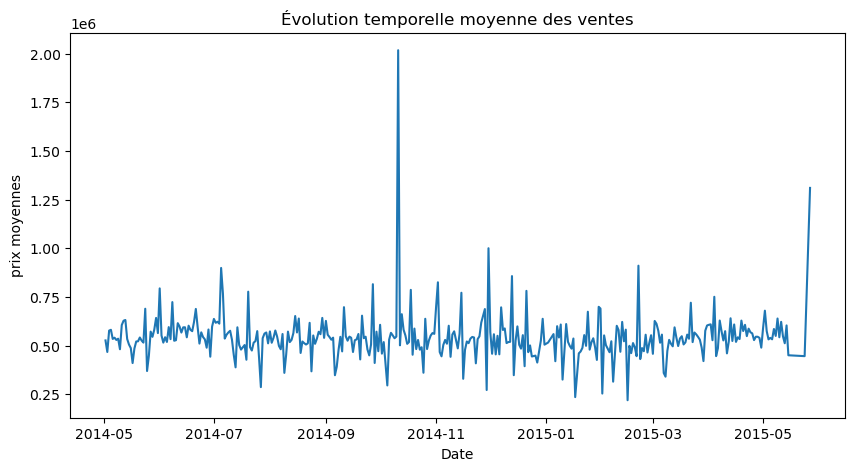

In [40]:
df_ts = df.groupby(level=0)["price"].mean()

plt.figure(figsize=(10,5))
plt.plot(df_ts)
plt.xlabel("Date")
plt.ylabel("prix moyennes")
plt.title("Évolution temporelle moyenne des ventes")
plt.show()

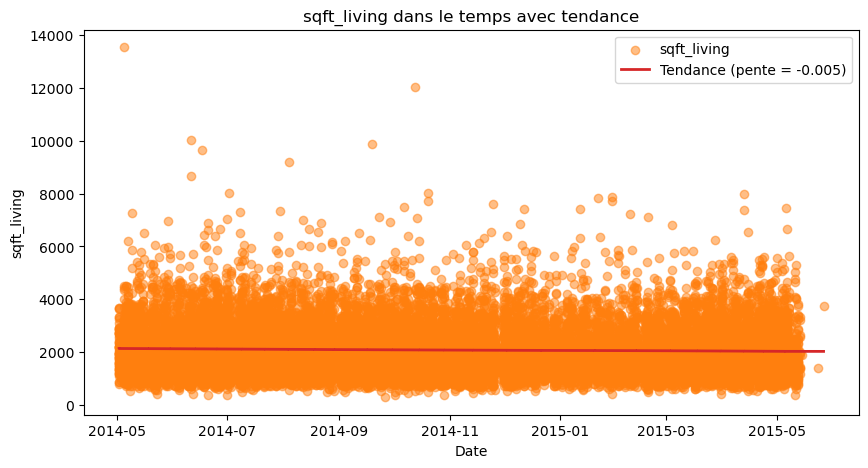

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Transformer le temps en variable numérique
t = np.arange(len(df))   # 0, 1, 2, ..., T
y = df["sqft_living"].values

# 2️⃣ Estimation de la tendance (régression linéaire simple)
slope, intercept = np.polyfit(t, y, 1)

# 3️⃣ Valeurs de la tendance
trend = intercept + slope * t

# 4️⃣ Plot
plt.figure(figsize=(10,5))

plt.scatter(
    df.index.get_level_values(0),
    y,
    color="tab:orange",
    alpha=0.5,
    label="sqft_living"
)

plt.plot(
    df.index.get_level_values(0),
    trend,
    color="tab:red",
    linewidth=2,
    label=f"Tendance (pente = {slope:.3f})"
)

plt.xlabel("Date")
plt.ylabel("sqft_living")
plt.title("sqft_living dans le temps avec tendance")
plt.legend()
plt.show()

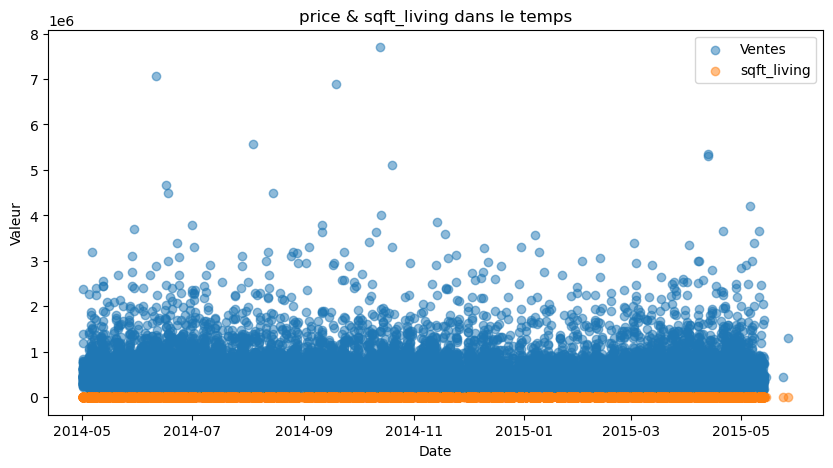

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.scatter(
    df.index.get_level_values(0),
    df["price"],
    alpha=0.5,
    label="Ventes"
)

plt.scatter(
    df.index.get_level_values(0),
    df["sqft_living"],
    alpha=0.5,
    label="sqft_living"
)

plt.xlabel("Date")
plt.ylabel("Valeur")
plt.title("price & sqft_living dans le temps")
plt.legend()
plt.show()

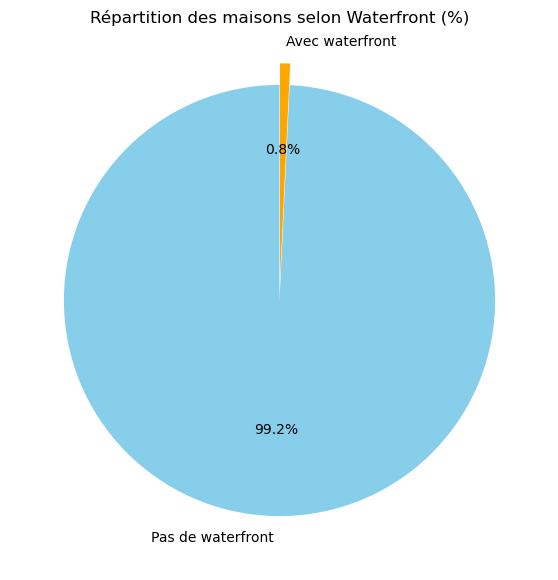

In [45]:
import matplotlib.pyplot as plt

# Compter les occurrences par catégorie
counts = df['waterfront'].value_counts()

# Calcul des pourcentages
pourcentages = counts / counts.sum() * 100

# Graphe circulaire
plt.figure(figsize=(7,7))
pourcentages.plot(
    kind='pie',
    autopct='%1.1f%%',  # affiche les pourcentages
    startangle=90,
    labels=['Pas de waterfront', 'Avec waterfront'],  # optionnel
    colors=['skyblue', 'orange'],
    explode=[0, 0.1]  # pour faire ressortir la catégorie 1
)
plt.ylabel('')
plt.title("Répartition des maisons selon Waterfront (%)")
plt.show()

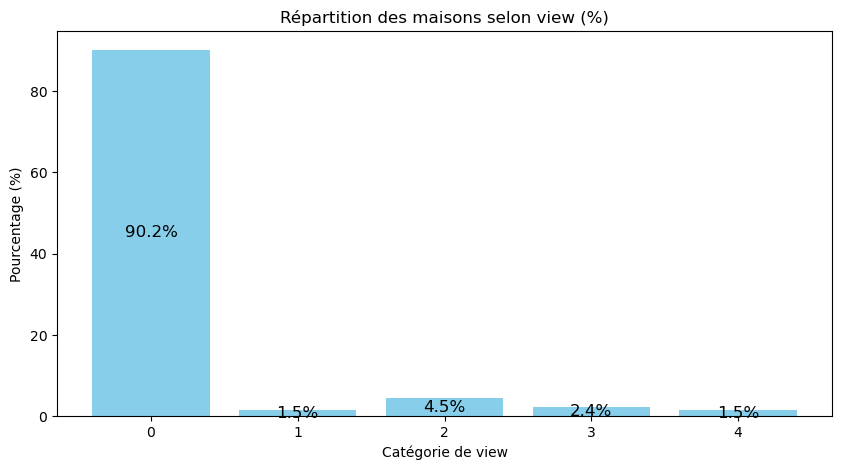

In [46]:
import matplotlib.pyplot as plt

# Compter les occurrences par catégorie et trier
view_counts = df['view'].value_counts().sort_index()
view_percent = view_counts / view_counts.sum() * 100

# Créer le graphique
plt.figure(figsize=(10,5))
bars = plt.bar(view_percent.index, view_percent.values, color='skyblue')

# Ajouter les pourcentages sur les barres (en noir)
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,  # centre horizontal
        height/2,                         # milieu vertical de la barre
        f'{height:.1f}%',                 # texte : pourcentage
        ha='center', va='center', color='black', fontsize=12
    )

plt.xlabel("Catégorie de view")
plt.ylabel("Pourcentage (%)")
plt.title("Répartition des maisons selon view (%)")
plt.xticks(rotation=0)
plt.show()

In [48]:
import pandas as pd

desc = df.describe().T   # transpose pour lisibilité

desc["skewness"] = df.skew(numeric_only=True)
desc["kurtosis"] = df.kurtosis(numeric_only=True)
desc["missing_%"] = df.isna().mean() * 100

desc

C:\AW_PythoN\Lib\site-packages\pandas\core\nanops.py:1256: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean
C:\AW_PythoN\Lib\site-packages\pandas\core\nanops.py:1344: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


,count,mean,min,25%,50%,75%,max,std,skewness,kurtosis,missing_%
price,21613.0,540088.141767,75000.0,321950.0,450000.0,645000.0,7700000.0,367127.196483,4.024069,34.585540,0.0
bedrooms,21613.0,3.370842,0.0,3.0,3.0,4.0,33.0,0.930062,1.974300,49.063653,0.0
bathrooms,21613.0,2.114757,0.0,1.75,2.25,2.5,8.0,0.770163,0.511108,1.279902,0.0
sqft_living,21613.0,2079.899736,290.0,1427.0,1910.0,2550.0,13540.0,918.440897,1.471555,5.243093,0.0
sqft_lot,21613.0,15106.967566,520.0,5040.0,7618.0,10688.0,1651359.0,41420.511515,13.060019,285.077820,0.0
floors,21613.0,1.494309,1.0,1.0,1.5,2.0,3.5,0.539989,0.616177,-0.484723,0.0
waterfront,21613.0,0.007542,0.0,0.0,0.0,0.0,1.0,0.086517,11.385108,127.632494,0.0
view,21613.0,0.234303,0.0,0.0,0.0,0.0,4.0,0.766318,3.395750,10.893022,0.0
condition,21613.0,2.40943,0.0,2.0,2.0,3.0,4.0,0.650743,1.032805,0.525764,0.0
grade,21613.0,7.656873,1.0,7.0,7.0,8.0,13.0,1.175459,0.771103,1.190932,0.0


# 4.Analyse Bivarié des variables (Features and target)

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sélectionner uniquement les colonnes numériques (exclure les qualitatives)
quali_vars = ['waterfront', 'view', 'condition', 'grade', 'zipcode', 'isrenovat']
numeric_df = df.drop(columns=quali_vars)

# Calculer la matrice de corrélation
corr_matrix = numeric_df.corr()

In [50]:
corr_matrix

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,sqft_above,sqft_basement,lat,long,...,house_age,total_rooms,M_sqft,R_Prliv,basement_ratio,lot_ratio,lot_Sum,lot_Dif,yr_built_date,renovated_date
price,1.000000,0.308350,0.525138,0.702035,0.089661,0.256794,0.605567,0.323816,0.307003,0.021626,...,-0.053951,0.466319,0.559407,0.554703,0.135539,-0.023094,0.104801,0.074361,0.054012,0.105755
bedrooms,0.308350,1.000000,0.515884,0.576671,0.031703,0.175429,0.477600,0.303093,-0.008931,0.129473,...,-0.154324,0.895483,0.069508,-0.206069,0.196172,-0.063375,0.044310,0.018985,0.154179,0.165506
bathrooms,0.525138,0.515884,1.000000,0.754665,0.087740,0.500653,0.685342,0.283770,0.024573,0.223042,...,-0.506407,0.843260,0.340746,-0.091421,0.128827,-0.059209,0.104050,0.071262,0.506020,0.537165
sqft_living,0.702035,0.576671,0.754665,1.000000,0.172826,0.353949,0.876597,0.435043,0.052529,0.240223,...,-0.318488,0.753932,0.772370,-0.092314,0.207346,-0.019772,0.194209,0.151195,0.318049,0.343745
sqft_lot,0.089661,0.031703,0.087740,0.172826,1.000000,-0.005201,0.183512,0.015286,-0.085683,0.229521,...,-0.052990,0.065479,0.190464,-0.033822,-0.029353,0.832606,0.999763,0.999760,0.053080,0.052910
floors,0.256794,0.175429,0.500653,0.353949,-0.005201,1.000000,0.523885,-0.245705,0.049614,0.125419,...,-0.489640,0.370197,0.184972,0.003840,-0.345513,-0.076618,0.002637,-0.013096,0.489320,0.505408
sqft_above,0.605567,0.477600,0.685342,0.876597,0.183512,0.523885,1.000000,-0.051943,-0.000816,0.343803,...,-0.424248,0.655752,0.668486,-0.088618,-0.257840,0.004512,0.202127,0.164667,0.423899,0.435904
sqft_basement,0.323816,0.303093,0.283770,0.435043,0.015286,-0.245705,-0.051943,1.000000,0.110538,-0.144765,...,0.132865,0.337613,0.352072,-0.025762,0.912726,-0.049473,0.024832,0.005660,-0.133124,-0.102263
lat,0.307003,-0.008931,0.024573,0.052529,-0.085683,0.049614,-0.000816,0.110538,1.000000,-0.135512,...,0.147647,0.007164,0.071959,0.472049,0.116005,-0.090660,-0.084175,-0.087161,-0.148123,-0.135549
long,0.021626,0.129473,0.223042,0.240223,0.229521,0.125419,0.343803,-0.144765,-0.135512,1.000000,...,-0.409323,0.197123,0.173352,-0.236032,-0.212462,0.161727,0.233896,0.225003,0.409356,0.382966


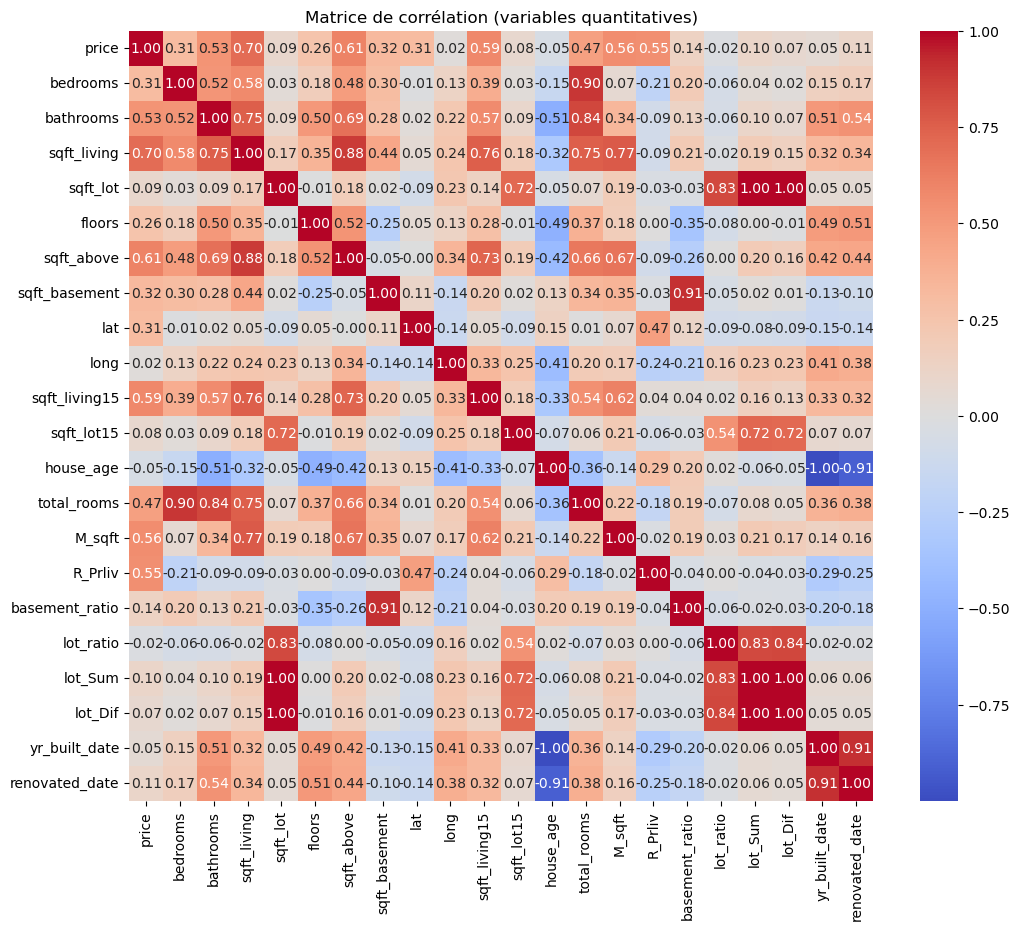

In [51]:
# Afficher la matrice avec seaborn
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation (variables quantitatives)")
plt.show()

# 5.Split Data 

In [55]:
#df.drop(columns = ["zipcode"])

In [56]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(1 , inplace=True)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [57]:
from sklearn.model_selection import train_test_split

# Séparer X et y
X = df.drop(columns=["price"])
y = df["price"]

In [58]:
#"bedrooms" ,"sqft_basement" ,"sqft_living", "sqft_lot" ,"lot_Dif" ,"total_rooms" ,"bathrooms" ,"sqft_above", "yr_built_date"

In [60]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, shuffle=False
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, shuffle=False
)

In [61]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

coords_train = scaler.fit_transform(X_train[["lat","long"]])
coords_valid = scaler.transform(X_val[["lat","long"]])
coords_test = scaler.transform(X_test[["lat","long"]])

In [62]:
coords_train

array([[-0.71861119,  1.5774418 ],
       [ 0.87791485, -1.31514535],
       [ 0.12323306,  1.33698223],
       ...,
       [ 0.76169821, -1.15248152],
       [ 1.26506152, -0.74228579],
       [-0.418627  , -1.06761344]], shape=(15129, 2))

In [65]:
import warnings
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')

inertia = []
K_range = range(2,15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(coords_train)
    inertia.append(kmeans.inertia_)

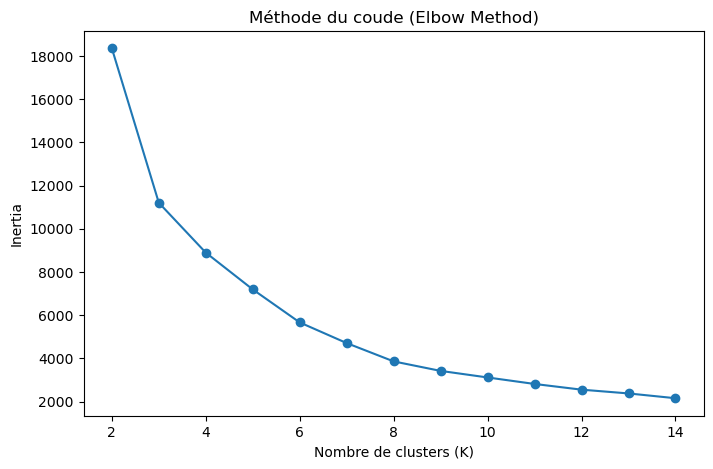

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertia")
plt.title("Méthode du coude (Elbow Method)")
plt.show()

In [67]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(coords_train)
    
    score = silhouette_score(coords_train, labels)
    sil_scores.append(score)

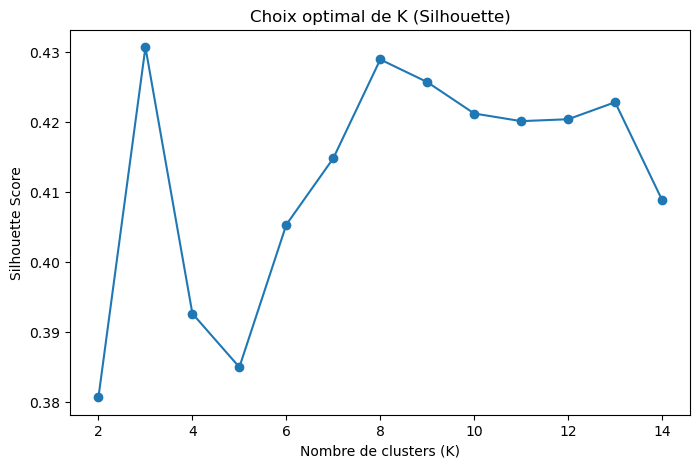

In [68]:
plt.figure(figsize=(8,5))
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Choix optimal de K (Silhouette)")
plt.show()

In [69]:
kmeans_final = KMeans(
    n_clusters=8,
    n_init=10,
    random_state=42
)

X_train["geo_cluster"] = kmeans_final.fit_predict(coords_train)
X_val["geo_cluster"] = kmeans_final.predict(coords_valid)
X_test["geo_cluster"] = kmeans_final.predict(coords_test)

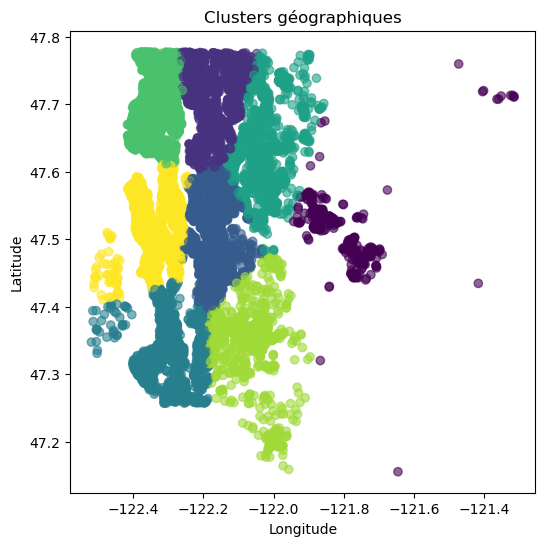

In [70]:
plt.figure(figsize=(6,6))

plt.scatter(
    X_train["long"],
    X_train["lat"],
    c=X_train["geo_cluster"],
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Clusters géographiques")

plt.show()

In [71]:
import joblib

joblib.dump(kmeans_final, "kmeans_geo.pkl")

['kmeans_geo.pkl']

In [73]:
quali_vars = ['waterfront', 'view', 'condition', 'grade', 'isrenovat', 'zipcode', 'geo_cluster']
time_vars = ['yr_built_date', 'renovated_date']

num_vars = [col for col in X_train.columns 
            if col not in quali_vars]

In [74]:
X_train['yr_built_date'] = X_train['yr_built_date'].dt.year
X_val['yr_built_date'] = X_val['yr_built_date'].dt.year
X_test['yr_built_date'] = X_test['yr_built_date'].dt.year

In [75]:
X_train['renovated_date'] = X_train['renovated_date'].dt.year
X_val['renovated_date'] = X_val['renovated_date'].dt.year
X_test['renovated_date'] = X_test['renovated_date'].dt.year

In [77]:
X_train[num_vars].dtypes

bedrooms            int64
bathrooms         float64
sqft_living         int64
sqft_lot            int64
floors            float64
sqft_above          int64
sqft_basement       int64
lat               float64
long              float64
sqft_living15       int64
sqft_lot15          int64
house_age           int64
total_rooms       float64
M_sqft            float64
R_Prliv           float64
basement_ratio    float64
lot_ratio         float64
lot_Sum             int64
lot_Dif             int64
yr_built_date       int32
renovated_date      int32
dtype: object

In [78]:
print("Nombre de +inf :", np.isinf(X_train[num_vars]).sum().sum())
print("Nombre de -inf :", np.isneginf(X_train[num_vars]).sum().sum())
print("Nombre de NaN  :", np.isnan(X_train[num_vars]).sum().sum())

Nombre de +inf : 0
Nombre de -inf : 0
Nombre de NaN  : 0


In [79]:
print("Nombre de +inf :", np.isinf(X_test[num_vars]).sum().sum())
print("Nombre de -inf :", np.isneginf(X_test[num_vars]).sum().sum())
print("Nombre de NaN  :", np.isnan(X_test[num_vars]).sum().sum())

Nombre de +inf : 0
Nombre de -inf : 0
Nombre de NaN  : 0


In [80]:
print("Nombre de +inf :", np.isinf(X_val[num_vars]).sum().sum())
print("Nombre de -inf :", np.isneginf(X_val[num_vars]).sum().sum())
print("Nombre de NaN  :", np.isnan(X_val[num_vars]).sum().sum())

Nombre de +inf : 0
Nombre de -inf : 0
Nombre de NaN  : 0


In [81]:
for col in num_vars:
    if np.isinf(X_train[col]).any():
        print("Inf dans :", col)

In [82]:
print(X_train.columns)

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'zipcode', 'lat', 'long', 'sqft_living15',
       'sqft_lot15', 'house_age', 'total_rooms', 'M_sqft', 'R_Prliv',
       'basement_ratio', 'lot_ratio', 'lot_Sum', 'lot_Dif', 'isrenovat',
       'yr_built_date', 'renovated_date', 'geo_cluster'],
      dtype='object')


In [83]:
# ===============================
# 📌 Target Encoding - zipcode
# ===============================

# Calcul mean sur train
zip_mean = (
    pd.concat([X_train, y_train], axis=1)
    .groupby("zipcode")["price"]
    .mean()
)

# Mapping
X_train["zipcode_te"] = X_train["zipcode"].map(zip_mean)
X_val["zipcode_te"]   = X_val["zipcode"].map(zip_mean)
X_test["zipcode_te"]  = X_test["zipcode"].map(zip_mean)

# Fill unseen
global_mean = y_train.mean()

X_train["zipcode_te"] = X_train["zipcode_te"].fillna(global_mean)
X_val["zipcode_te"]   = X_val["zipcode_te"].fillna(global_mean)
X_test["zipcode_te"]  = X_test["zipcode_te"].fillna(global_mean)

In [84]:
# Vérifier les premières lignes
X_train[["zipcode_te"]].head()

zipcode_te
date       virtual_id               
2014-05-02 0           615309.593857
           1           573988.716049
           2           611474.059574
           3           521064.742718
           4           833093.265363

In [85]:
# Appliquer log1p pour compresser les grandes valeurs
X_train["zipcode_te"] = np.log(X_train["zipcode_te"])
X_val["zipcode_te"]   = np.log(X_val["zipcode_te"])
X_test["zipcode_te"]  = np.log(X_test["zipcode_te"])

In [86]:
# Vérifier les premières lignes
X_train[["zipcode_te"]].head()

zipcode_te
date       virtual_id            
2014-05-02 0            13.329881
           1            13.260365
           2            13.323628
           3            13.163630
           4            13.632901

In [87]:
# Combien de valeurs uniques dans la colonne encodée
print("Nombre de valeurs uniques avant TE :", X_train["zipcode"].nunique())

Nombre de valeurs uniques avant TE : 70


In [88]:
# Combien de valeurs uniques dans la colonne encodée
print("Nombre de valeurs uniques après TE :", X_train["zipcode_te"].nunique())

Nombre de valeurs uniques après TE : 70


In [89]:
# Drop original
X_train = X_train.drop(columns=["zipcode"])
X_val   = X_val.drop(columns=["zipcode"])
X_test  = X_test.drop(columns=["zipcode"])

In [91]:
quali_vars = ['waterfront', 'view', 'condition', 'grade', 'isrenovat', 'zipcode_te', 'geo_cluster']
time_vars = ['yr_built_date', 'renovated_date']

num_vars = [col for col in X_train.columns 
            if col not in quali_vars]

In [92]:
X_train[num_vars].describe

<bound method NDFrame.describe of                        bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
date       virtual_id                                                       
2014-05-02 0                  3       2.25         1970     35100     2.0   
           1                  3       2.50         2600      4750     1.0   
           2                  5       2.50         2820     67518     2.0   
           3                  4       2.50         3310      6500     2.0   
           4                  4       2.25         2160      8119     1.0   
...                         ...        ...          ...       ...     ...   
2015-01-16 24                 3       2.50         1820     16300     1.0   
           25                 4       1.50         2820      4000     2.0   
           26                 3       2.50         1040      1032     3.0   
           27                 3       1.50         1330      6768     1.0   
           28                 2       1.00

In [93]:
# ===============================
# 📌 1. Définition des groupes
# ===============================

feature_groups = {

    "Nombre_pieces": [
        "bedrooms",
        "bathrooms",
        "total_rooms"
    ],

    "Surface": [
        "sqft_living",
        "sqft_above",
        "sqft_basement",
        "sqft_living15",
        "M_sqft",
        "R_Prliv"
    ],

    "Lot": [
        "sqft_lot",
        "sqft_lot15",
        "lot_ratio",
        "lot_Dif",
        "lot_Sum"
    ],

    "Chronologie": [
        "yr_built_date",
        "house_age",
        "renovated_date",
        "isrenovat"
    ],

    "Qualite_Condition": [
        "grade",
        "condition"
    ],

    "Localisation": [
        "lat",
        "long",
        "zipcode",
        "waterfront",
        "view"
    ]
}

In [94]:
from IPython.display import display, Markdown

for group, variables in feature_groups.items():
    display(Markdown(f"## 📂 {group}"))
    for var in variables:
        display(Markdown(f"- {var}"))

## 📂 Nombre_pieces

- bedrooms

- bathrooms

- total_rooms

## 📂 Surface

- sqft_living

- sqft_above

- sqft_basement

- sqft_living15

- M_sqft

- R_Prliv

## 📂 Lot

- sqft_lot

- sqft_lot15

- lot_ratio

- lot_Dif

- lot_Sum

## 📂 Chronologie

- yr_built_date

- house_age

- renovated_date

- isrenovat

## 📂 Qualite_Condition

- grade

- condition

## 📂 Localisation

- lat

- long

- zipcode

- waterfront

- view

# 6.Feature Selection & Standarisation

In [95]:
quali_vars = ['waterfront', 'view', 'condition', 'grade', 'isrenovat', 'zipcode_te', 'geo_cluster']
time_vars = ['yr_built_date', 'renovated_date']

num_vars = [col for col in X_train.columns 
            if col not in quali_vars]

In [96]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[num_vars] = scaler.fit_transform(X_train[num_vars])

X_val[num_vars] = scaler.transform(X_val[num_vars])
X_test[num_vars] = scaler.transform(X_test[num_vars])

In [97]:
means = scaler.mean_
stds = scaler.scale_

In [98]:
import pandas as pd

scaler_params = pd.DataFrame({
    "Feature": num_vars,
    "Mean (μ)": means,
    "Std (σ)": stds
})

scaler_params

,Feature,Mean (μ),Std (σ)
0,bedrooms,3.378743,0.943012
1,bathrooms,2.129189,0.773154
2,sqft_living,2098.695155,930.850402
3,sqft_lot,15054.728006,38657.190896
4,floors,1.501586,0.540572
5,sqft_above,1802.477031,836.489074
6,sqft_basement,296.218124,448.861765
7,lat,47.562434,0.137674
8,long,-122.214044,0.141396
9,sqft_living15,1997.913610,692.523263


In [100]:
type(X_train)

pandas.core.frame.DataFrame

In [101]:
X_train = X_train.drop(columns = ['long', 'lat'])

In [103]:
#Tant que ne depasse pas seuil de 5 en VIF ,on peut juger comme acceptable (15 features pour les modèles parametrique)

In [104]:
X_train.dtypes

bedrooms          float64
bathrooms         float64
sqft_living       float64
sqft_lot          float64
floors            float64
waterfront          int64
view                int64
condition           int64
grade               int64
sqft_above        float64
sqft_basement     float64
sqft_living15     float64
sqft_lot15        float64
house_age         float64
total_rooms       float64
M_sqft            float64
R_Prliv           float64
basement_ratio    float64
lot_ratio         float64
lot_Sum           float64
lot_Dif           float64
isrenovat           int64
yr_built_date     float64
renovated_date    float64
geo_cluster         int32
zipcode_te        float64
dtype: object

In [105]:
X_train.shape

(15129, 26)

In [107]:
X_train=X_train.values.reshape(15129, 26)

In [108]:
type(X_train)

numpy.ndarray

In [110]:
X_train.shape

(15129, 26)

In [111]:
X_test = X_test.drop(columns = ['long', 'lat'])

In [113]:
X_val = X_val.drop(columns = ['long', 'lat'])

In [115]:
list(df.columns)

['price',
 'bedrooms',
 'bathrooms',
 'sqft_living',
 'sqft_lot',
 'floors',
 'waterfront',
 'view',
 'condition',
 'grade',
 'sqft_above',
 'sqft_basement',
 'zipcode',
 'lat',
 'long',
 'sqft_living15',
 'sqft_lot15',
 'house_age',
 'total_rooms',
 'M_sqft',
 'R_Prliv',
 'basement_ratio',
 'lot_ratio',
 'lot_Sum',
 'lot_Dif',
 'isrenovat',
 'yr_built_date',
 'renovated_date']

In [116]:
type(X_test)

pandas.core.frame.DataFrame

In [117]:
type(X_val)

pandas.core.frame.DataFrame

In [118]:
X_test.dtypes

bedrooms          float64
bathrooms         float64
sqft_living       float64
sqft_lot          float64
floors            float64
waterfront          int64
view                int64
condition           int64
grade               int64
sqft_above        float64
sqft_basement     float64
sqft_living15     float64
sqft_lot15        float64
house_age         float64
total_rooms       float64
M_sqft            float64
R_Prliv           float64
basement_ratio    float64
lot_ratio         float64
lot_Sum           float64
lot_Dif           float64
isrenovat           int64
yr_built_date     float64
renovated_date    float64
geo_cluster         int32
zipcode_te        float64
dtype: object

In [119]:
X_val.dtypes

bedrooms          float64
bathrooms         float64
sqft_living       float64
sqft_lot          float64
floors            float64
waterfront          int64
view                int64
condition           int64
grade               int64
sqft_above        float64
sqft_basement     float64
sqft_living15     float64
sqft_lot15        float64
house_age         float64
total_rooms       float64
M_sqft            float64
R_Prliv           float64
basement_ratio    float64
lot_ratio         float64
lot_Sum           float64
lot_Dif           float64
isrenovat           int64
yr_built_date     float64
renovated_date    float64
geo_cluster         int32
zipcode_te        float64
dtype: object

In [120]:
X_test.shape

(3242, 26)

In [121]:
X_val.shape

(3242, 26)

In [122]:
X_test=X_test.values.reshape(3242, 26)

In [123]:
X_val=X_val.values.reshape(3242, 26)

In [124]:
type(X_test)

numpy.ndarray

In [125]:
type(X_val)

numpy.ndarray

In [128]:
X_test.shape

(3242, 26)

In [129]:
X_val.shape

(3242, 26)

In [130]:
type(y_train)

pandas.core.series.Series

In [131]:
type(y_test)

pandas.core.series.Series

In [132]:
type(y_val)

pandas.core.series.Series

In [133]:
print(type(X_train))
print(type(X_test))
print(type(X_val))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [134]:
print(X_train[:1, :30])   # première colonne

[[-4.01630760e-01  1.56257332e-01 -1.38255465e-01  5.18539282e-01
   9.22012153e-01  0.00000000e+00  0.00000000e+00  3.00000000e+00
   9.00000000e+00  2.00269166e-01 -6.59931737e-01  4.93970974e-01
   8.31420973e-01 -2.06168325e-01 -1.72531588e-01  5.83612088e-03
  -3.61330076e-01 -7.30925945e-01  5.52195570e-01  5.12834981e-01
   5.24001430e-01  0.00000000e+00  2.05050718e-01  1.20619295e-01
   6.00000000e+00  1.33298808e+01]]


In [135]:
print(y_train.shape)
print(y_test.shape)
print(y_val.shape)

(15129,)
(3242,)
(3242,)


In [136]:
y_train=y_train.values.reshape(15129, 1)
y_test=y_test.values.reshape(3242, 1)
y_val=y_val.values.reshape(3242, 1)

In [137]:
print(y_train.shape)
print(y_test.shape)
print(y_val.shape)

(15129, 1)
(3242, 1)
(3242, 1)


In [138]:
print(type(y_train))
print(type(y_test))
print(type(y_val))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


# 7.Regression Multiple : OLS, Decision Tree, Random forest, XGBoost ,LigthGBM

In [140]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

In [141]:
#9.1 Regression Multiple : OLS, Decision Tree, Random forest

In [142]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [143]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [144]:
print("R² Train =", r2_score(y_train, y_pred_train))
print("R² Test =", r2_score(y_test, y_pred_test))

print("RMSE Train =", root_mean_squared_error(y_train, y_pred_train))
print("RMSE Test =", root_mean_squared_error(y_test, y_pred_test))

R² Train = 0.8912906787948123
R² Test = 0.8786277639121167
RMSE Train = 121974.67952339073
RMSE Test = 131467.72554986345


In [145]:
model = DecisionTreeRegressor(
    random_state=42
)

model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [146]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [147]:
print("R² Train =", r2_score(y_train, y_pred_train))
print("R² Test =", r2_score(y_test, y_pred_test))

print("RMSE Train =", root_mean_squared_error(y_train, y_pred_train))
print("RMSE Test =", root_mean_squared_error(y_test, y_pred_test))

R² Train = 1.0
R² Test = 0.9826160226423674
RMSE Train = 0.0
RMSE Test = 49754.69252713529


In [148]:
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [149]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [150]:
print("R² Train =", r2_score(y_train, y_pred_train))
print("R² Test =", r2_score(y_test, y_pred_test))

print("RMSE Train =", root_mean_squared_error(y_train, y_pred_train))
print("RMSE Test =", root_mean_squared_error(y_test, y_pred_test))

R² Train = 0.9989959826483318
R² Test = 0.9924049783136369
RMSE Train = 11722.139973511185
RMSE Test = 32886.97907941374


In [151]:
model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [152]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [153]:
print("R² Train =", r2_score(y_train, y_pred_train))
print("R² Test =", r2_score(y_test, y_pred_test))

print("RMSE Train =", root_mean_squared_error(y_train, y_pred_train))
print("RMSE Test =", root_mean_squared_error(y_test, y_pred_test))

R² Train = 0.9948354833888838
R² Test = 0.9928516372211887
RMSE Train = 26585.88568667954
RMSE Test = 31905.29505897041


In [154]:
model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=-1,
    num_leaves=31,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000930 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3589
[LightGBM] [Info] Number of data points in the train set: 15129, number of used features: 26
[LightGBM] [Info] Start training from score 539105.337498


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [155]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

In [156]:
print("R² Train =", r2_score(y_train, y_pred_train))
print("R² Test =", r2_score(y_test, y_pred_test))

print("RMSE Train =", root_mean_squared_error(y_train, y_pred_train))
print("RMSE Test =", root_mean_squared_error(y_test, y_pred_test))

R² Train = 0.9941989155863564
R² Test = 0.9947024768846627
RMSE Train = 28176.74919479342
RMSE Test = 27466.030824108664


#  7.Validation Croisee de XGBoost & Deployement

In [157]:
xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=1.2,
    random_state=42
)

xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [158]:
y_pred_train = xgb.predict(X_train)
y_pred_test = xgb.predict(X_test)

print("R² Train =", r2_score(y_train, y_pred_train))
print("R² Test =", r2_score(y_test, y_pred_test))

print("RMSE Train =", root_mean_squared_error(y_train, y_pred_train))
print("RMSE Test =", root_mean_squared_error(y_test, y_pred_test))

R² Train = 0.9990785199014168
R² Test = 0.956156322115114
RMSE Train = 11229.987524195461
RMSE Test = 79015.62180736728


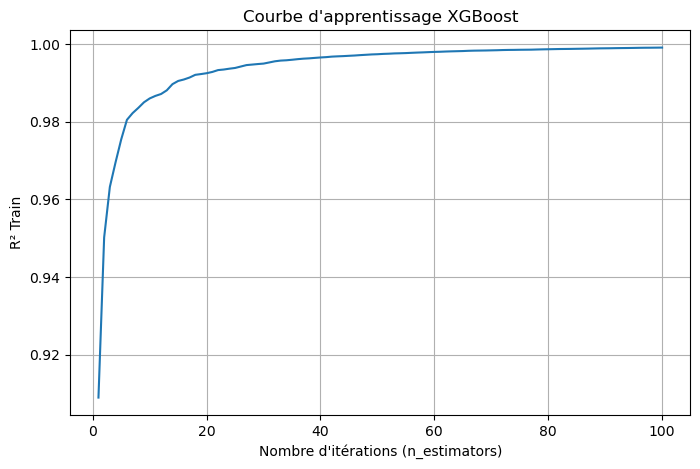

In [159]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

r2_train = []

for n in range(1, 101):

    model = XGBRegressor(
        n_estimators=n,
        learning_rate=1.2,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_train)

    r2_train.append(
        r2_score(y_train, y_pred)
    )

plt.figure(figsize=(8,5))

plt.plot(
    range(1,101),
    r2_train
)

plt.xlabel("Nombre d'itérations (n_estimators)")
plt.ylabel("R² Train")
plt.title("Courbe d'apprentissage XGBoost")

plt.grid(True)
plt.show()

In [160]:
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error

y_pred_val = xgb.predict(X_val)

print("R² Validation =", r2_score(y_val, y_pred_val))
print("RMSE Validation =", root_mean_squared_error(y_val, y_pred_val))

R² Validation = 0.9553264767294949
RMSE Validation = 72224.66516721604


In [161]:
y_train_pred = xgb.predict(X_train)

print("R² Train =", r2_score(y_train, y_pred_train))
print("R² Test =", r2_score(y_test, y_pred_test))
print("R² Validation =", r2_score(y_val, y_pred_val))

R² Train = 0.9990785199014168
R² Test = 0.956156322115114
R² Validation = 0.9553264767294949


In [162]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

cv = KFold(
    n_splits=5,
    shuffle=False
)

scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=cv,
    scoring='r2'
)

print(scores)
print(scores.mean())
print(scores.std())

[0.95787752 0.94750993 0.93441638 0.93361945 0.9585957 ]
0.9464037977236242
0.010850346183222503
